### Imports

In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import metric as mt
import matplotlib.ticker as ticker
from glob import glob

In [2]:
with open('gene_list/genes.smn1_type.list','r') as inpf:
    smn1_type = inpf.read().splitlines()

with open('gene_list/genes.rhce_type.list','r') as inpf:
    rhce_type = inpf.read().splitlines()

with open('gene_list/genes.strc_type.list','r') as inpf:
    strc_type = inpf.read().splitlines()
    
with open('gene_list/genes.cd177_type.list','r') as inpf:
    cd177_type = inpf.read().splitlines()
    
print(len(smn1_type), len(rhce_type), len(strc_type), len(cd177_type))

type1_dict = {g: 'type_1' for g in smn1_type}
type2_dict = {g: 'type_2' for g in rhce_type}
type3_dict = {g: 'type_3' for g in strc_type}
type4_dict = {g: 'type_4' for g in cd177_type}

all_types_dict = type1_dict | type2_dict | type3_dict | type4_dict

29 55 21 23


### All genes

In [3]:
pops = ['EUR']
centers = ['BCM','BGI','BI','WUGSC'] 
dfs = []

for i,pop in enumerate(pops):
    for center in centers:
        
        print('='*50)
        print(pop, center)
        
        fp = f'results-fullpipeline/{pop}.{center}.concat.eval.bed'
        df_result = pd.read_csv(fp, sep='\t')

        print('Number of genes:', len(df_result.gene.unique()))
        df_result = df_result.loc[df_result.alpha_beta > 1000]
        dfs.append(df_result)
        print(df_result['name'].unique().shape[0], 'samples')

EUR BCM
Number of genes: 134
156 samples
EUR BGI
Number of genes: 126
169 samples
EUR BI
Number of genes: 133
109 samples
EUR WUGSC
Number of genes: 135
72 samples


In [4]:
exclude = [
    'UPK3BL_refcn4', # high variance, high cn
    'UPK3BL_refcn6', # high variance, high cn
    'CCL4',          # high variation (2-9)
    'DDT',           # weird segdup structure
    'CEP170_refcn6', # refcn6 but has cn=4 for half the exons
    'SLX1A',         # one segdup but why is cn high?
    'CLEC18A',       # extreme cn
    'SERPINB3',      # half of the exons are cn=2
    'BOLA2',         # bad groundtruth for other pop
    'DEFA1',         # extreme cn
    'PGA3',          # high variation (4-10)
    'FCGBP'          # refCN says to be 4, but is 6
    'ORM1',          # outlier gene
    'GTF2I',         # outlier gene
]

all_dfs = []
for i,center in enumerate(centers):

    df = dfs[i].copy()
    df['refcn'] = df.refcn.astype('Int32')
    df = df.loc[~df.gene.isin(exclude)]

    # Compute reference and non-ref concordance
    df[[
        'ref_acc', 'ref_err', 'ref_fil', 'ref_acc_f', 'ref_err_f',
        'nref_acc', 'nref_err', 'nref_fil', 'nref_acc_f', 'nref_err_f'
    ]] = df.apply(lambda row: pd.Series(mt.v_correct3(row.hmm, row.truth, row.refcn)), axis=1)

    # Compute combined concordance
    df[[
        'comb_acc', 'comb_err', 'comb_fil', 'comb_acc_f', 'comb_err_f',
    ]] = df.apply(lambda row: pd.Series(mt.v_correct_combined(row.hmm, row.truth, row.refcn)), axis=1)

    # Add metadata columns
    df['num_exon'] = df.hmm.apply(lambda x: len(x.split(',')))
    df['num_samples'] = df['name'].unique().shape[0]
    df['gene_type'] = df['gene'].apply(lambda g: all_types_dict.get(g))
    
    all_dfs.append(df)
    
    print('='*60)
    print(center)
    
    df_acc = df[['comb_acc_f', 'ref_acc_f', 'nref_acc_f']].mean()
    print(df_acc)
    print()

    
print('='*60)
print('ALL')
all_df = pd.concat(all_dfs, axis=0)
df_acc_all = all_df[['comb_acc_f', 'ref_acc_f', 'nref_acc_f']].mean()
print(df_acc_all)

BCM
comb_acc_f    0.990123
ref_acc_f     0.995544
nref_acc_f    0.959799
dtype: float64

BGI
comb_acc_f    0.989097
ref_acc_f     0.995664
nref_acc_f    0.952960
dtype: float64

BI
comb_acc_f    0.983138
ref_acc_f     0.990706
nref_acc_f    0.938869
dtype: float64

WUGSC
comb_acc_f    0.977374
ref_acc_f     0.986859
nref_acc_f    0.924995
dtype: float64

ALL
comb_acc_f    0.986643
ref_acc_f     0.993429
nref_acc_f    0.948591
dtype: float64


### High sequence similarity genes

In [5]:
pops = ['EUR']
centers = ['BCM','BGI','BI','WUGSC'] 
dfs = []

for i,pop in enumerate(pops):
    for center in centers:
        
        print('='*50)
        print(pop, center)
        
        fp = f'results-fullpipeline/{pop}.{center}.concat.eval.bed'
        df_result = pd.read_csv(fp, sep='\t')

        print('Number of genes:', len(df_result.gene.unique()))
        df_result = df_result.loc[df_result.alpha_beta > 1000]
        dfs.append(df_result)
        print(df_result['name'].unique().shape[0], 'samples')

EUR BCM
Number of genes: 134
156 samples
EUR BGI
Number of genes: 126
169 samples
EUR BI
Number of genes: 133
109 samples
EUR WUGSC
Number of genes: 135
72 samples


In [6]:
exclude = [
    'UPK3BL_refcn4', # high variance, high cn
    'UPK3BL_refcn6', # high variance, high cn
    'CCL4',          # high variation (2-9)
    'DDT',           # weird segdup structure
    'CEP170_refcn6', # refcn6 but has cn=4 for half the exons
    'SLX1A',         # one segdup but why is cn high?
    'CLEC18A',       # extreme cn
    'SERPINB3',      # half of the exons are cn=2
    'BOLA2',         # bad groundtruth for other pop
    'DEFA1',         # extreme cn
    'PGA3',          # high variation (4-10)
    'FCGBP'          # refCN says to be 4, but is 6
    'ORM1',          # outlier gene
    'GTF2I',         # outlier gene
]

all_dfs = []
for i,center in enumerate(centers):

    df = dfs[i].copy()
    df['refcn'] = df.refcn.astype('Int32')
    df = df.loc[~df.gene.isin(exclude)]

    # Compute reference and non-ref concordance
    df[[
        'ref_acc', 'ref_err', 'ref_fil', 'ref_acc_f', 'ref_err_f',
        'nref_acc', 'nref_err', 'nref_fil', 'nref_acc_f', 'nref_err_f'
    ]] = df.apply(lambda row: pd.Series(mt.v_correct3(row.hmm, row.truth, row.refcn)), axis=1)

    # Compute combined concordance
    df[[
        'comb_acc', 'comb_err', 'comb_fil', 'comb_acc_f', 'comb_err_f',
    ]] = df.apply(lambda row: pd.Series(mt.v_correct_combined(row.hmm, row.truth, row.refcn)), axis=1)

    df['num_exon'] = df.hmm.apply(lambda x: len(x.split(',')))
    df['num_samples'] = df['name'].unique().shape[0]
    df['gene_type'] = df['gene'].apply(lambda g: all_types_dict.get(g))
    df['gene_type2'] = df['gene_type'].apply(lambda g: 'high_ss' if g in ['type_1','type_3']else 'low_ss')
    
    all_dfs.append(df)
    
    print('='*60)
    print(center)
    
    df_acc = pd.DataFrame(df.groupby('gene_type2')[['comb_acc_f', 'ref_acc_f', 'nref_acc_f']].mean()).reset_index()
    print(df_acc)
    print()

    
print('='*60)
print('ALL')
all_df = pd.concat(all_dfs, axis=0)
df_acc_all = pd.DataFrame(all_df.groupby('gene_type2')[['comb_acc_f', 'ref_acc_f', 'nref_acc_f']].mean()).reset_index()
print(df_acc_all)

BCM
  gene_type2  comb_acc_f  ref_acc_f  nref_acc_f
0    high_ss    0.986962   0.994423    0.968052
1     low_ss    0.991736   0.995992    0.945740

BGI
  gene_type2  comb_acc_f  ref_acc_f  nref_acc_f
0    high_ss    0.987126   0.995332    0.966308
1     low_ss    0.990087   0.995795    0.931666

BI
  gene_type2  comb_acc_f  ref_acc_f  nref_acc_f
0    high_ss    0.977672   0.988379    0.949395
1     low_ss    0.985849   0.991618    0.921413

WUGSC
  gene_type2  comb_acc_f  ref_acc_f  nref_acc_f
0    high_ss    0.974460   0.987892    0.942115
1     low_ss    0.978835   0.986460    0.894684

ALL
  gene_type2  comb_acc_f  ref_acc_f  nref_acc_f
0    high_ss    0.983438   0.992602    0.960150
1     low_ss    0.988256   0.993756    0.929359


### Rare and common genes

In [13]:
df_ref = pd.read_csv('ablation.tsv', sep='\t')
df_ref['rare_comm'] = df_ref.apply(lambda r: 'rare' if r.is_ref/r.num_samples>0.95 else 'comm', axis=1)
rare_comm = df_ref[['gene', 'rare_comm']].set_index("gene")["rare_comm"].to_dict()

In [14]:
pops = ['EUR']
centers = ['BCM','BGI','BI','WUGSC'] 
dfs = []

for i,pop in enumerate(pops):
    for center in centers:
        
        print('='*50)
        print(pop, center)
        
        fp = f'results-fullpipeline/{pop}.{center}.concat.eval.bed'
        df_result = pd.read_csv(fp, sep='\t')
        df_result['rare_comm'] = df_result.gene.apply(lambda g: rare_comm.get(g, 'rare'))

        print('Number of genes:', len(df_result.gene.unique()))
        df_result = df_result.loc[df_result.alpha_beta > 1000]
        dfs.append(df_result)
        print(df_result['name'].unique().shape[0], 'samples')

EUR BCM
Number of genes: 134
156 samples
EUR BGI
Number of genes: 126
169 samples
EUR BI
Number of genes: 133
109 samples
EUR WUGSC
Number of genes: 135
72 samples


In [15]:
exclude = [
    'UPK3BL_refcn4', # high variance, high cn
    'UPK3BL_refcn6', # high variance, high cn
    'CCL4',          # high variation (2-9)
    'DDT',           # weird segdup structure
    'CEP170_refcn6', # refcn6 but has cn=4 for half the exons
    'SLX1A',         # one segdup but why is cn high?
    'CLEC18A',       # extreme cn
    'SERPINB3',      # half of the exons are cn=2
    'BOLA2',         # bad groundtruth for other pop
    'DEFA1',         # extreme cn
    'PGA3',          # high variation (4-10)
    'FCGBP'          # refCN says to be 4, but is 6
    'ORM1',          # outlier gene
    'GTF2I',         # outlier gene
]


all_dfs = []
for i,center in enumerate(centers):

    df = dfs[i].copy()
    df['refcn'] = df.refcn.astype('Int32')
    df = df.loc[~df.gene.isin(exclude)]

    # Compute reference and non-ref concordance
    df[[
        'ref_acc', 'ref_err', 'ref_fil', 'ref_acc_f', 'ref_err_f',
        'nref_acc', 'nref_err', 'nref_fil', 'nref_acc_f', 'nref_err_f'
    ]] = df.apply(lambda row: pd.Series(mt.v_correct3(row.hmm, row.truth, row.refcn)), axis=1)

    # Compute combined concordance
    df[[
        'comb_acc', 'comb_err', 'comb_fil', 'comb_acc_f', 'comb_err_f',
    ]] = df.apply(lambda row: pd.Series(mt.v_correct_combined(row.hmm, row.truth, row.refcn)), axis=1)

    df['num_exon'] = df.hmm.apply(lambda x: len(x.split(',')))
    df['num_samples'] = df['name'].unique().shape[0]
    df['gene_type'] = df['gene'].apply(lambda g: all_types_dict.get(g))
    
    all_dfs.append(df)
    
    print('='*60)
    print(center)
    
    df_acc = pd.DataFrame(df.groupby('rare_comm')[['comb_acc_f', 'ref_acc_f', 'nref_acc_f']].mean()).reset_index()
    print(df_acc)
    print()

    
print('='*60)
print('ALL')
all_df = pd.concat(all_dfs, axis=0)
df_acc_all = pd.DataFrame(all_df.groupby(['rare_comm'])[['comb_acc_f', 'ref_acc_f', 'nref_acc_f']].mean()).reset_index()
print(df_acc_all)

BCM
  rare_comm  comb_acc_f  ref_acc_f  nref_acc_f
0      comm    0.978544   0.988332    0.963600
1      rare    0.996393   0.997951    0.917967

BGI
  rare_comm  comb_acc_f  ref_acc_f  nref_acc_f
0      comm    0.972350   0.984889    0.953775
1      rare    0.997833   0.999102    0.945744

BI
  rare_comm  comb_acc_f  ref_acc_f  nref_acc_f
0      comm    0.960359   0.970298    0.944044
1      rare    0.995341   0.997649    0.889824

WUGSC
  rare_comm  comb_acc_f  ref_acc_f  nref_acc_f
0      comm    0.942355   0.950589    0.930251
1      rare    0.996041   0.998590    0.865999

ALL
  rare_comm  comb_acc_f  ref_acc_f  nref_acc_f
0      comm    0.967919   0.978440    0.951843
1      rare    0.996612   0.998358    0.916476


In [16]:
# Number of genes with rare vs common CNVs
test = pd.DataFrame(all_df.groupby(['rare_comm','gene'])[['comb_acc_f', 'ref_acc_f', 'nref_acc_f']].mean()).reset_index()
test.rare_comm.value_counts()

rare_comm
rare    81
comm    43
Name: count, dtype: int64

### Visualization

In [11]:
# manually grabbed combined concordance from above
data = [
    ['Full Pipeline', 'All genes_comb',           0.986643],
    ['Full Pipeline', 'All genes_nref',           0.948591],
    ['Full Pipeline', 'High Seq Sim genes',       0.983438],
    ['Full Pipeline', 'Common CNV genes',         0.967919],
    
    ['Fractional Ablation', 'All genes_comb',     0.965219], 
    ['Fractional Ablation', 'All genes_nref',     0.837373], 
    ['Fractional Ablation', 'High Seq Sim genes', 0.974109],
    ['Fractional Ablation', 'Common CNV genes',   0.939229],
    
    ['JLF Ablation', 'All genes_comb',            0.888406],
    ['JLF Ablation', 'All genes_nref',            0.441468],
    ['JLF Ablation', 'High Seq Sim genes',        0.838437],
    ['JLF Ablation', 'Common CNV genes',          0.705835],
]

df = pd.DataFrame(data)
df.columns = ['Method', 'Gene Type', "Concordance",]
df

,Method,Gene Type,Concordance
0,Full Pipeline,All genes_comb,0.986643
1,Full Pipeline,All genes_nref,0.948591
2,Full Pipeline,High Seq Sim genes,0.983438
3,Full Pipeline,Common CNV genes,0.967919
4,Fractional Ablation,All genes_comb,0.965219
5,Fractional Ablation,All genes_nref,0.837373
6,Fractional Ablation,High Seq Sim genes,0.974109
7,Fractional Ablation,Common CNV genes,0.939229
8,JLF Ablation,All genes_comb,0.888406
9,JLF Ablation,All genes_nref,0.441468


/tmp/ipykernel_28063/906016784.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["All genes",


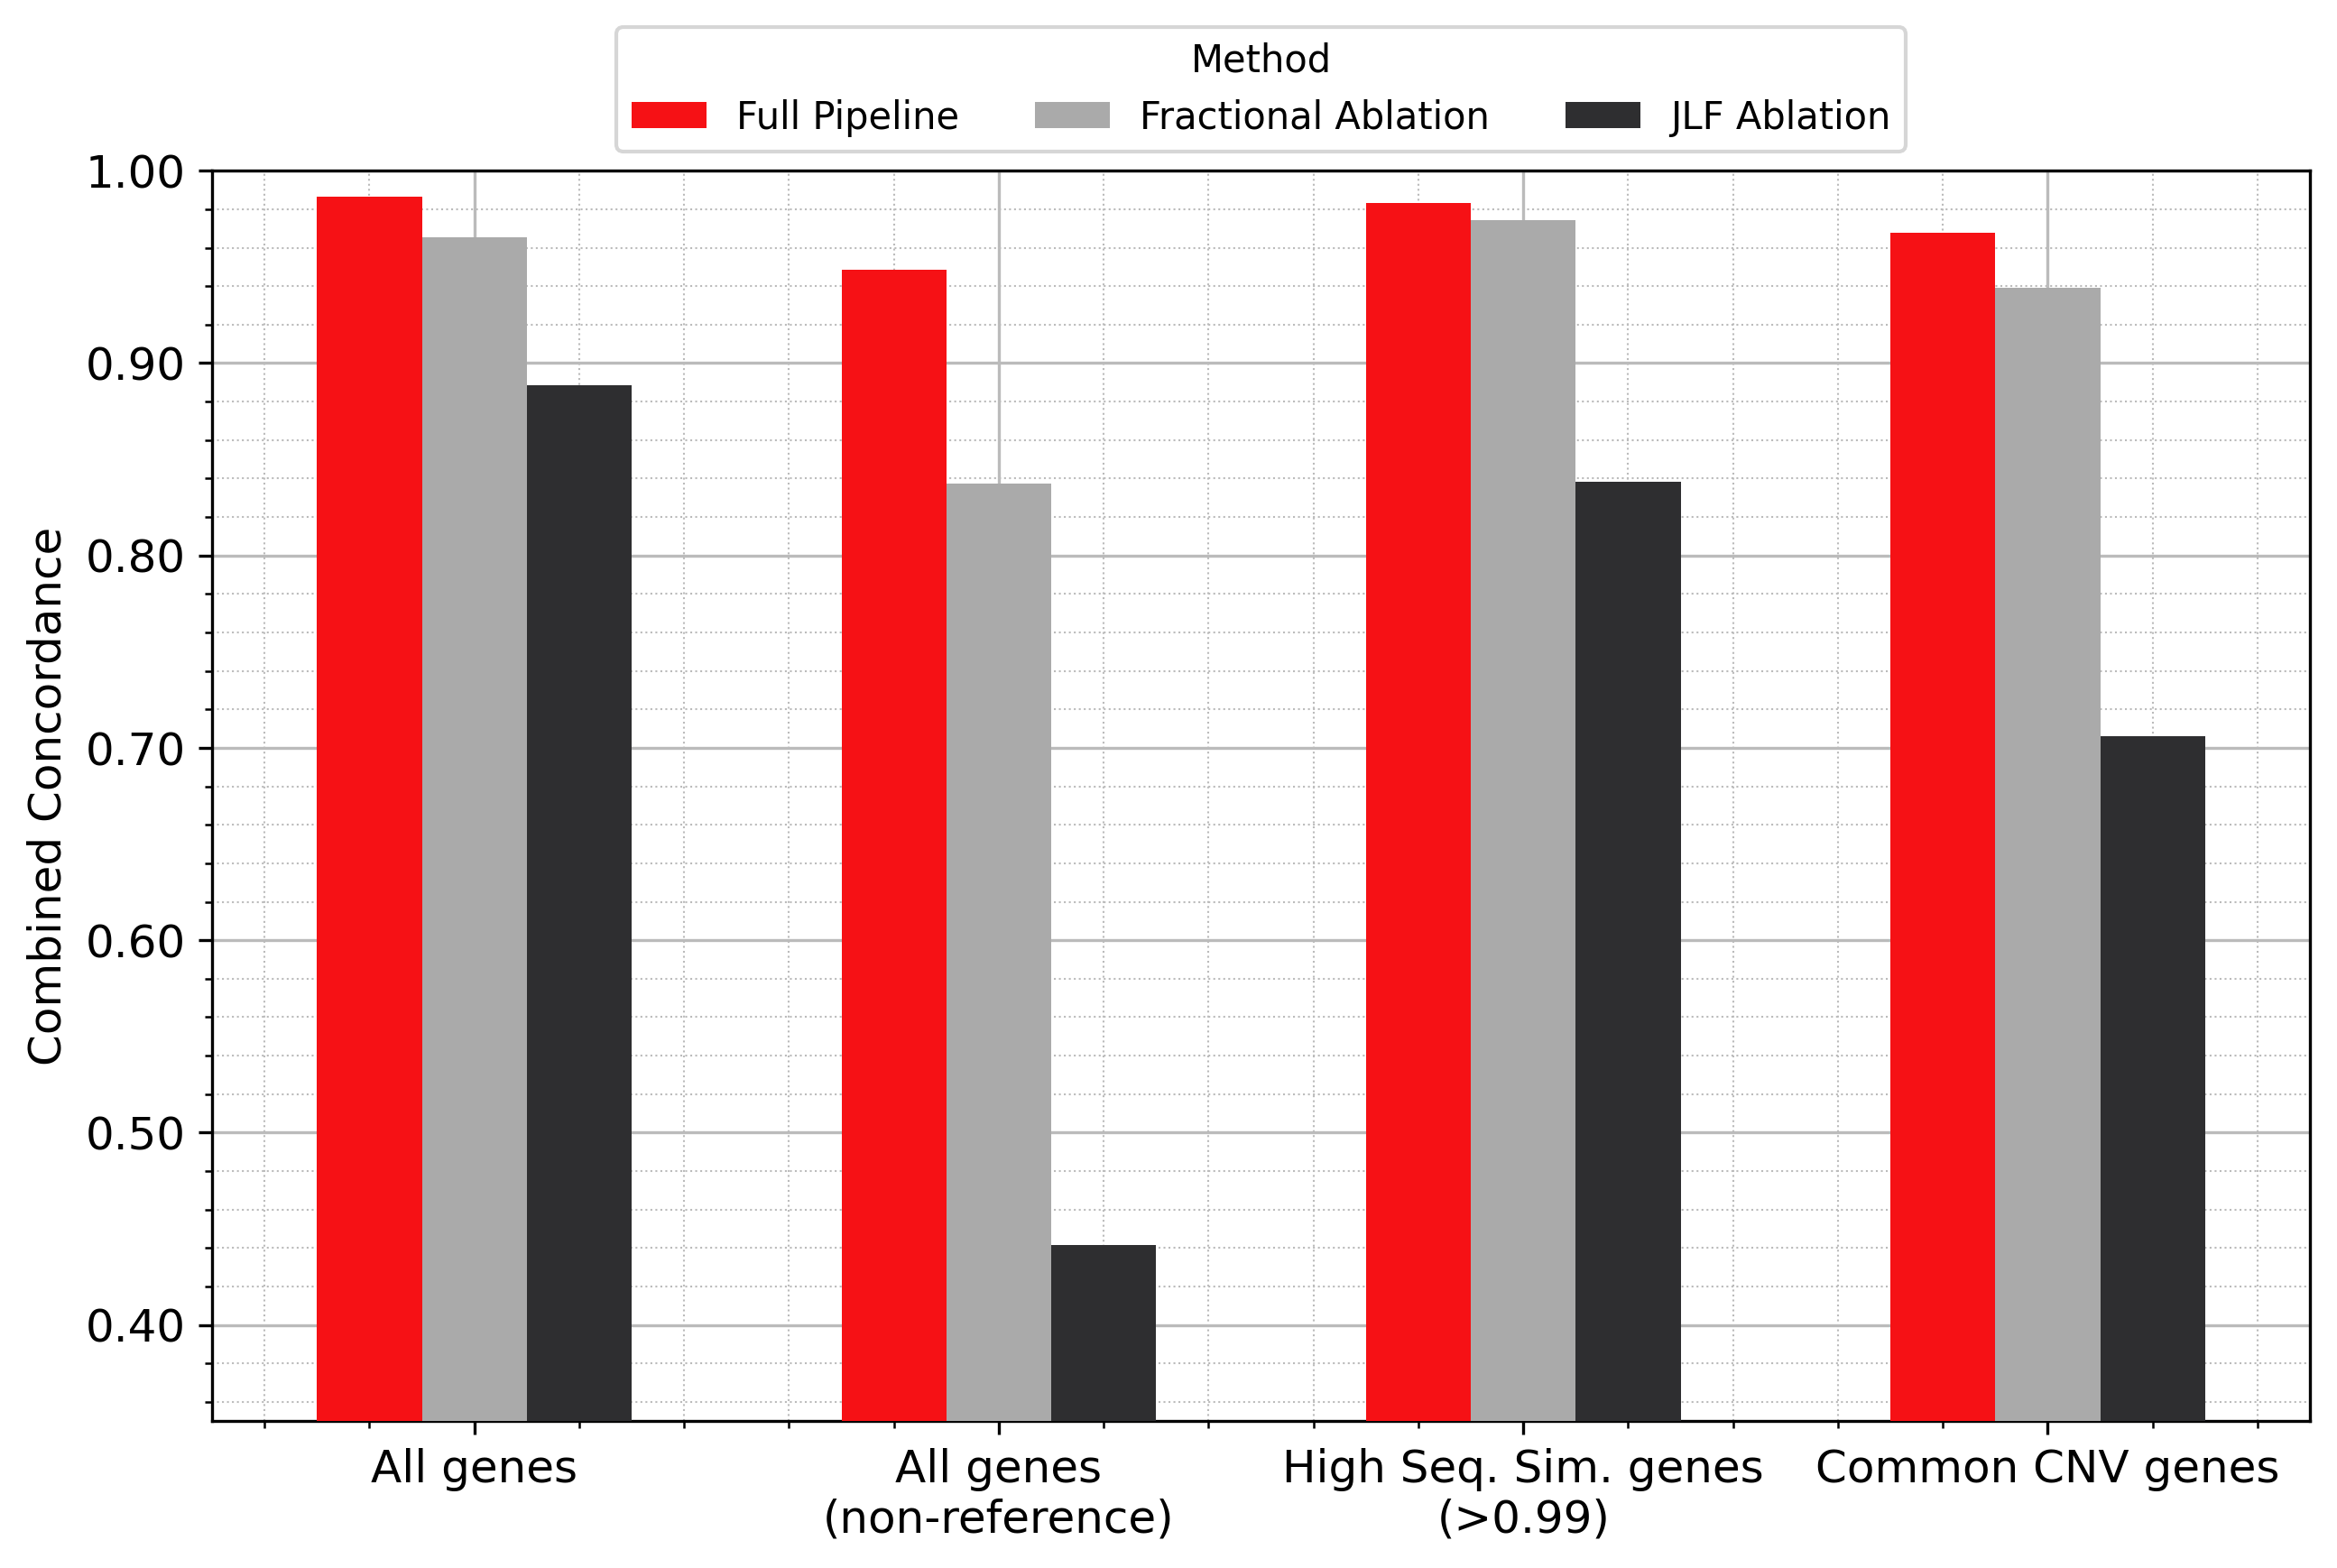

In [12]:
plt.figure(figsize=(10, 6), dpi=300)

my_colors = ['#F61115','#AAAAAA', '#2E2E30']

ax = sns.barplot(df, x="Gene Type", y="Concordance", hue="Method", 
                 zorder=100, palette=my_colors, saturation=1, width=0.6)

# Formatting
ax.grid(which='major', color='#BBBBBB', linewidth=0.8, zorder=-100)
ax.grid(which='minor', color='#BBBBBB', linestyle=':', linewidth=0.5, zorder=-100)
ax.minorticks_on()
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.set_xticklabels(["All genes", 
                    "All genes\n(non-reference)",
                    "High Seq. Sim. genes\n(>0.99)", 
                    "Common CNV genes"])


plt.ylim(0.35, 1.0)
plt.ylabel("Combined Concordance", fontsize=12)
plt.xlabel(None)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Method', loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3)
plt.show()